<a href="https://colab.research.google.com/github/gopika-vit/-AI-DS-/blob/main/Phishing_email_detection_using_NB_and_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PHISHING EMAIL DETECTION USING NAIVE BAYES

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -U scikit-learn pandas nltk joblib
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
import os
import re
import joblib
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

In [ ]:
CSV_PATH = "/content/drive/MyDrive/Phishing_Email.csv"
TEXT_COL = "Email Text"
LABEL_COL = "Email Type"


In [ ]:
NROWS = None
MAX_FEATURES = 5000
TEST_SIZE = 0.2
RANDOM_STATE = 42
STOPWORDS = set(stopwords.words('english'))
stemmer = PorterStemmer()
le = LabelEncoder()

In [ ]:
# Text cleaning & preprocessing helpers
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess_text(text):
    text = clean_text(text)
    # tokenization
    tokens = word_tokenize(text)
    # remove stopwords & one-letter tokens, stem
    tokens = [stemmer.stem(t) for t in tokens if t not in STOPWORDS and len(t) > 1]
    return " ".join(tokens)

def preprocess_series(series):
    # apply with progress bar and avoid memory bloat
    out = []
    for t in tqdm(series, desc="Preprocessing"):
        out.append(preprocess_text(t))
    return out


In [ ]:
print("Loading:", CSV_PATH)
df = pd.read_csv(CSV_PATH, nrows=NROWS)
print("Columns:", df.columns.tolist())

if TEXT_COL not in df.columns or LABEL_COL not in df.columns:
    raise ValueError(f"CSV must contain columns '{TEXT_COL}' and '{LABEL_COL}'")

# Drop NA rows for the required columns, remove duplicates
df = df[[TEXT_COL, LABEL_COL]].dropna().drop_duplicates(subset=[TEXT_COL]).reset_index(drop=True)
print("Records after dropna & dedup:", len(df))

# Preprocess text (this prints progress)
df['clean_text'] = preprocess_series(df[TEXT_COL].astype(str))

# Encode labels to integers (0/1)
df[LABEL_COL] = le.fit_transform(df[LABEL_COL].astype(str))
print("Label mapping:", dict(zip(le.classes_, range(len(le.classes_)))))


Loading: /content/drive/MyDrive/Phishing_Email.csv
Columns: ['Unnamed: 0', 'Email Text', 'Email Type']
Records after dropna & dedup: 17537


Preprocessing:   0%|          | 0/17537 [00:00<?, ?it/s]

Label mapping: {'Phishing Email': 0, 'Safe Email': 1}


In [ ]:
# TF-IDF vectorization + train/test split
X = df['clean_text'].astype(str).to_numpy()
y = df[LABEL_COL].astype(int).to_numpy()

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

tfidf = TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=(1,1), stop_words=None)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("TF-IDF shape (train):", X_train_tfidf.shape)
print("TF-IDF shape (test):", X_test_tfidf.shape)


TF-IDF shape (train): (14029, 5000)
TF-IDF shape (test): (3508, 5000)


In [ ]:
# Train MultinomialNB, ComplementNB, BernoulliNB, GaussianNB with GridSearch

from sklearn.naive_bayes import MultinomialNB, ComplementNB, BernoulliNB, GaussianNB
from sklearn.preprocessing import Binarizer, StandardScaler

ALPHAS = [0.1, 0.5, 1.0]
FIT_PRIOR = [True, False]
VAR_SMOOTHING = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]

def run_grid(model, param_grid, X, y, cv=5, scoring='balanced_accuracy'):
    grid = GridSearchCV(model, param_grid, cv=cv, scoring=scoring, n_jobs=-1, verbose=1)
    grid.fit(X, y)
    return grid


# --- 1️⃣ MultinomialNB ---
print("\n🔹 Training MultinomialNB (GridSearch)...")
mnb = MultinomialNB()
params_mnb = {"alpha": ALPHAS, "fit_prior": FIT_PRIOR}
grid_mnb = run_grid(mnb, params_mnb, X_train_tfidf, y_train)
print("MNB best:", grid_mnb.best_params_, "CV score:", grid_mnb.best_score_)


# --- 2️⃣ ComplementNB ---
print("\n🔹 Training ComplementNB (GridSearch)...")
cnb = ComplementNB()
params_cnb = {"alpha": ALPHAS, "fit_prior": FIT_PRIOR}
grid_cnb = run_grid(cnb, params_cnb, X_train_tfidf, y_train)
print("CNB best:", grid_cnb.best_params_, "CV score:", grid_cnb.best_score_)


# --- 3️⃣ BernoulliNB ---
# Convert TF-IDF to binary presence/absence; avoid full dense to save memory
print("\n🔹 Training BernoulliNB (GridSearch)...")
binarizer = Binarizer(threshold=0.0)
# convert to dense in small batches to prevent OOM
X_train_bin = binarizer.fit_transform(X_train_tfidf.toarray())
X_test_bin = binarizer.transform(X_test_tfidf.toarray())

bnb = BernoulliNB()
params_bnb = {"alpha": ALPHAS, "fit_prior": FIT_PRIOR}
grid_bnb = run_grid(bnb, params_bnb, X_train_bin, y_train)
print("BNB best:", grid_bnb.best_params_, "CV score:", grid_bnb.best_score_)


# --- 4️⃣ GaussianNB ---
# GaussianNB requires dense numeric input
print("\n🔹 Training GaussianNB (GridSearch)...")
# scale only a few thousand samples to avoid RAM overflow
X_train_dense = X_train_tfidf[:15000].toarray() if X_train_tfidf.shape[0] > 15000 else X_train_tfidf.toarray()
y_train_small = y_train[:15000] if X_train_tfidf.shape[0] > 15000 else y_train
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train_dense)

gnb = GaussianNB()
params_gnb = {"var_smoothing": VAR_SMOOTHING}
grid_gnb = run_grid(gnb, params_gnb, X_train_scaled, y_train_small)
print("GNB best:", grid_gnb.best_params_, "CV score:", grid_gnb.best_score_)



🔹 Training MultinomialNB (GridSearch)...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
MNB best: {'alpha': 0.5, 'fit_prior': False} CV score: 0.9622199797574517

🔹 Training ComplementNB (GridSearch)...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
CNB best: {'alpha': 0.5, 'fit_prior': True} CV score: 0.9622199797574517

🔹 Training BernoulliNB (GridSearch)...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
BNB best: {'alpha': 0.1, 'fit_prior': True} CV score: 0.9263190034224766

🔹 Training GaussianNB (GridSearch)...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
GNB best: {'var_smoothing': 1e-05} CV score: 0.9226096734894954



MultinomialNB evaluation:
Accuracy: 0.9592 | Balanced: 0.9602 | Precision: 0.9781 | Recall: 0.9563 | F1: 0.9671
Classification report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.95      1312
           1       0.98      0.96      0.97      2196

    accuracy                           0.96      3508
   macro avg       0.95      0.96      0.96      3508
weighted avg       0.96      0.96      0.96      3508



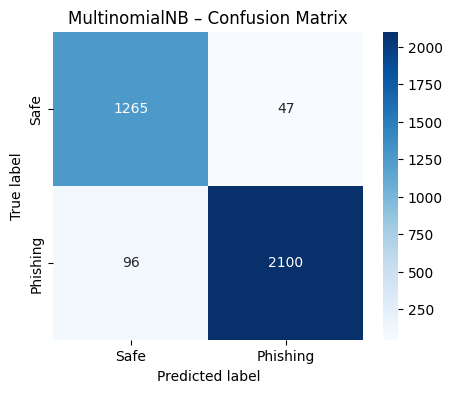


ComplementNB evaluation:
Accuracy: 0.9592 | Balanced: 0.9602 | Precision: 0.9781 | Recall: 0.9563 | F1: 0.9671
Classification report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.95      1312
           1       0.98      0.96      0.97      2196

    accuracy                           0.96      3508
   macro avg       0.95      0.96      0.96      3508
weighted avg       0.96      0.96      0.96      3508



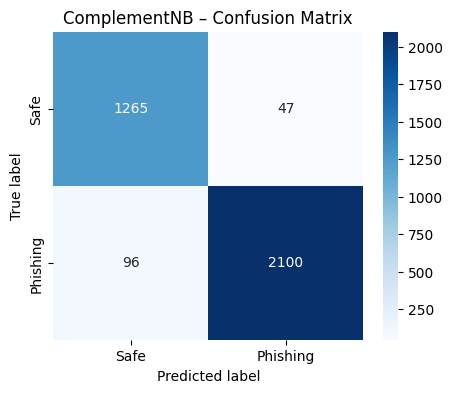


BernoulliNB evaluation:
Accuracy: 0.9145 | Balanced: 0.9280 | Precision: 0.9877 | Recall: 0.8743 | F1: 0.9275
Classification report:
               precision    recall  f1-score   support

           0       0.82      0.98      0.90      1312
           1       0.99      0.87      0.93      2196

    accuracy                           0.91      3508
   macro avg       0.91      0.93      0.91      3508
weighted avg       0.93      0.91      0.92      3508



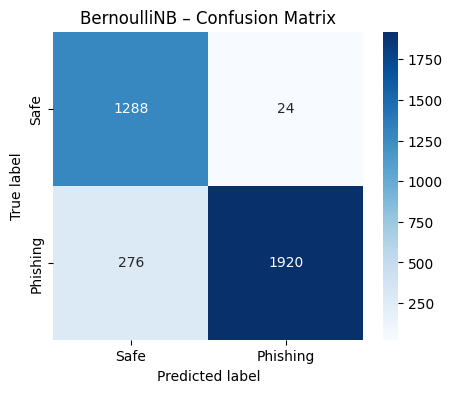


GaussianNB evaluation:
Accuracy: 0.9202 | Balanced: 0.9175 | Precision: 0.9435 | Recall: 0.9281 | F1: 0.9357
Classification report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.89      1312
           1       0.94      0.93      0.94      2196

    accuracy                           0.92      3508
   macro avg       0.91      0.92      0.92      3508
weighted avg       0.92      0.92      0.92      3508



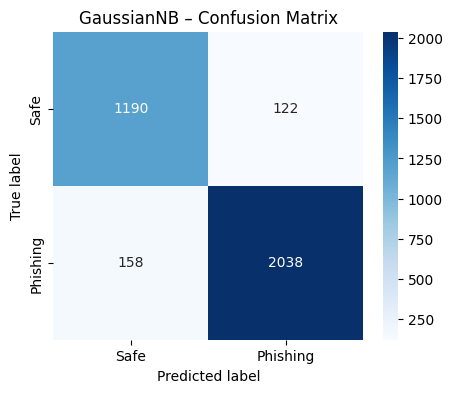

,acc,bal,pre,rec,f1
MultinomialNB,0.959236,0.960230,0.978109,0.956284,0.967073
ComplementNB,0.959236,0.960230,0.978109,0.956284,0.967073
BernoulliNB,0.914481,0.928012,0.987654,0.874317,0.927536
GaussianNB,0.920182,0.917532,0.943519,0.928051,0.935721


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_and_plot(model, X_test, y_test, name="Model"):
    preds = model.predict(X_test)

    acc  = accuracy_score(y_test, preds)
    bal  = balanced_accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='binary', zero_division=0)
    rec  = recall_score(y_test, preds, average='binary', zero_division=0)
    f1   = f1_score(y_test, preds, average='binary', zero_division=0)

    print(f"\n{name} evaluation:")
    print(f"Accuracy: {acc:.4f} | Balanced: {bal:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print("Classification report:\n", classification_report(y_test, preds, zero_division=0))

    # --- Confusion Matrix Visualization ---
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Safe','Phishing'],
                yticklabels=['Safe','Phishing'])
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.title(f'{name} – Confusion Matrix')
    plt.show()

    return {"acc": acc, "bal": bal, "pre": prec, "rec": rec, "f1": f1}


# ---- Evaluate all trained models ----
results = {}
results["MultinomialNB"] = evaluate_and_plot(grid_mnb.best_estimator_, X_test_tfidf, y_test, "MultinomialNB")
results["ComplementNB"]  = evaluate_and_plot(grid_cnb.best_estimator_, X_test_tfidf, y_test, "ComplementNB")

# If you trained the other two:
try:
    results["BernoulliNB"] = evaluate_and_plot(grid_bnb.best_estimator_, X_test_bin, y_test, "BernoulliNB")
except Exception as e:
    print("BernoulliNB not available:", e)

try:
    X_test_dense  = X_test_tfidf[:15000].toarray() if X_test_tfidf.shape[0] > 15000 else X_test_tfidf.toarray()
    X_test_scaled = scaler.transform(X_test_dense)
    results["GaussianNB"] = evaluate_and_plot(grid_gnb.best_estimator_, X_test_scaled,
                                              y_test[:len(X_test_scaled)], "GaussianNB")
except Exception as e:
    print("GaussianNB not available:", e)


# Optional: summary table
pd.DataFrame(results).T

In [ ]:
# Store all models and their cross-validation scores
model_scores = {}

try:
    model_scores["MultinomialNB"] = grid_mnb.best_score_
except:
    pass

try:
    model_scores["ComplementNB"] = grid_cnb.best_score_
except:
    pass

try:
    model_scores["BernoulliNB"] = grid_bnb.best_score_
except:
    pass

try:
    model_scores["GaussianNB"] = grid_gnb.best_score_
except:
    pass

# Display summary
print("\nCross-validation scores (balanced accuracy):")
for k, v in model_scores.items():
    print(f"{k:15s} -> {v:.4f}")

# --- Select the model with the best score ---
best_model_name = max(model_scores, key=model_scores.get)
print(f"\n✅ Best model based on CV balanced accuracy: {best_model_name}")

# Map name to trained estimator object
model_map = {
    "MultinomialNB": grid_mnb.best_estimator_ if 'grid_mnb' in locals() else None,
    "ComplementNB": grid_cnb.best_estimator_ if 'grid_cnb' in locals() else None,
    "BernoulliNB":  grid_bnb.best_estimator_ if 'grid_bnb' in locals() else None,
    "GaussianNB":   grid_gnb.best_estimator_ if 'grid_gnb' in locals() else None
}

final_model = model_map[best_model_name]
final_name = best_model_name.lower().replace(" ", "_")

# --- Save all models (for later use) ---
save_dir = "/content/drive/MyDrive/nb_models"
os.makedirs(save_dir, exist_ok=True)

for name, mdl in model_map.items():
    if mdl is not None:
        path = os.path.join(save_dir, f"{name.lower()}_tfidf_model.joblib")
        joblib.dump({"tfidf": tfidf, "label_encoder": le, "model": mdl}, path)
        print(f"💾 Saved {name} -> {path}")

# --- Save the final best model separately for quick access ---
final_path = os.path.join(save_dir, f"best_{final_name}_tfidf_model.joblib")
joblib.dump({"tfidf": tfidf, "label_encoder": le, "model": final_model}, final_path)
print(f"\n🏆 Best model '{best_model_name}' saved as: {final_path}")




Cross-validation scores (balanced accuracy):
MultinomialNB   -> 0.9622
ComplementNB    -> 0.9622
BernoulliNB     -> 0.9263
GaussianNB      -> 0.9226

✅ Best model based on CV balanced accuracy: MultinomialNB
💾 Saved MultinomialNB -> /content/drive/MyDrive/nb_models/multinomialnb_tfidf_model.joblib
💾 Saved ComplementNB -> /content/drive/MyDrive/nb_models/complementnb_tfidf_model.joblib
💾 Saved BernoulliNB -> /content/drive/MyDrive/nb_models/bernoullinb_tfidf_model.joblib
💾 Saved GaussianNB -> /content/drive/MyDrive/nb_models/gaussiannb_tfidf_model.joblib

🏆 Best model 'MultinomialNB' saved as: /content/drive/MyDrive/nb_models/best_multinomialnb_tfidf_model.joblib


In [ ]:
# Load best saved model automatically & predict new emails

import os, joblib

# Directory where all models were saved in Cell 9
save_dir = "/content/drive/MyDrive/nb_models"

# Auto-detect the "best_..." model file
best_file = None
for f in os.listdir(save_dir):
    if f.startswith("best_") and f.endswith(".joblib"):
        best_file = os.path.join(save_dir, f)
        break

if best_file is None:
    raise FileNotFoundError(f"No file starting with 'best_' found in {save_dir}. Check Cell 9 output.")

print(f"✅ Loading best model from: {best_file}")
saved = joblib.load(best_file)

tfidf = saved["tfidf"]
le = saved["label_encoder"]
final_model = saved["model"]

# --- Define helper for new email predictions ---
def predict_email(text, model, tfidf, label_encoder):
    from IPython.display import Markdown as md
    clean = preprocess_text(text)
    vec = tfidf.transform([clean])
    pred = model.predict(vec)[0]
    label = label_encoder.inverse_transform([pred])[0]
    human = "Phishing Mail ⚠️" if pred == 0 else "Safe Mail ✅"
    display(md(f"**Input:** {text}\n\n**Predicted Label:** {label} → **{human}**"))
    return pred

# --- Try a few sample predictions ---
predict_email("Please verify your bank details immediately at http://fakebank.com", final_model, tfidf, le)
predict_email("Reminder: project meeting tomorrow at 11 AM in the conference room.", final_model, tfidf, le)
predict_email("Update your account now to avoid suspension.", final_model, tfidf, le)


✅ Loading best model from: /content/drive/MyDrive/nb_models/best_multinomialnb_tfidf_model.joblib


**Input:** Please verify your bank details immediately at http://fakebank.com

**Predicted Label:** Phishing Email → **Phishing Mail ⚠️**

**Input:** Reminder: project meeting tomorrow at 11 AM in the conference room.

**Predicted Label:** Safe Email → **Safe Mail ✅**

**Input:** Update your account now to avoid suspension.

**Predicted Label:** Phishing Email → **Phishing Mail ⚠️**

np.int64(0)

/tmp/ipykernel_4728/2950896617.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Balanced Accuracy", y="Model", data=scores_df, palette="viridis")


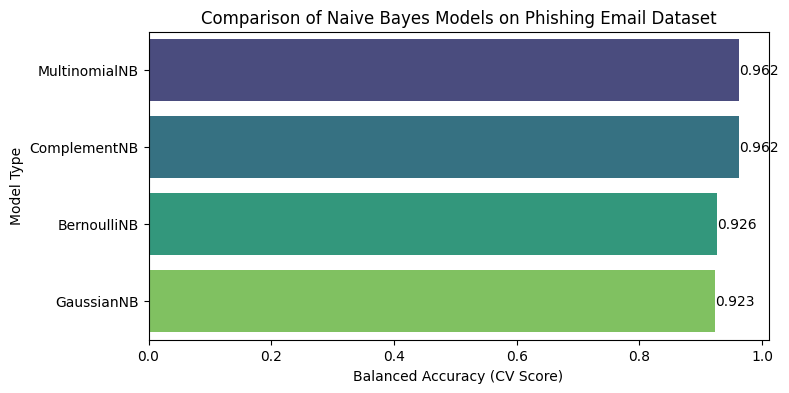

In [ ]:
# Visual comparison of model performance
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert the dictionary to a DataFrame
scores_df = pd.DataFrame(list(model_scores.items()), columns=["Model", "Balanced Accuracy"])
scores_df = scores_df.sort_values("Balanced Accuracy", ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(x="Balanced Accuracy", y="Model", data=scores_df, palette="viridis")
plt.title("Comparison of Naive Bayes Models on Phishing Email Dataset")
plt.xlabel("Balanced Accuracy (CV Score)")
plt.ylabel("Model Type")
for index, row in scores_df.iterrows():
    plt.text(row["Balanced Accuracy"] + 0.001, index, f"{row['Balanced Accuracy']:.3f}", va='center')
plt.show()


PHISHING EMAIL DETECTION USING NLP TECHNIQUE

In [ ]:
import shutil, os

# Unmount attempt (ignore errors)
os.system("fusermount -u /content/drive")

# Delete the stale mount folder
if os.path.exists("/content/drive"):
    shutil.rmtree("/content/drive", ignore_errors=True)

# Recreate empty mount folder
os.makedirs("/content/drive", exist_ok=True)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -U "transformers>=4.45.0" "datasets>=2.20.0" "evaluate>=0.4.2" accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 13.4 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
!pip install -q transformers datasets evaluate accelerate seqeval
!pip install -U transformers accelerate datasets evaluate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import os, math, random
import pandas as pd
import numpy as np
from datasets import Dataset, DatasetDict
import evaluate
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
CSV_PATH = "/content/drive/MyDrive/Phishing_Email.csv"
TEXT_COL = "Email Text"
LABEL_COL = "Email Type"
NROWS = None         # set None for full data
MODEL_NAME = "distilbert-base-uncased"
OUTPUT_DIR = "/content/drive/MyDrive/distilbert_phishing"
MAX_LEN = 128
BATCH_SIZE = 8
EPOCHS = 3
LEARNING_RATE = 2e-5
FP16 = True
SEED = 42
# -----------------------

set_seed(SEED)
os.makedirs(OUTPUT_DIR, exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [ ]:
print("Loading CSV:", CSV_PATH)
df = pd.read_csv(CSV_PATH, nrows=NROWS)

# Basic checks
print("Columns:", df.columns.tolist())
if TEXT_COL not in df.columns or LABEL_COL not in df.columns:
    raise ValueError(f"CSV must contain '{TEXT_COL}' and '{LABEL_COL}' columns. Found: {df.columns.tolist()}")

# Drop NA and duplicates (like earlier pipeline)
df = df[[TEXT_COL, LABEL_COL]].dropna().drop_duplicates(subset=[TEXT_COL]).reset_index(drop=True)
print("Total rows after dropna & dedup:", len(df))

# Optional light cleaning (lowercase, remove weird whitespace). Keep content intact for transformers.
def light_clean(s):
    if not isinstance(s, str):
        return ""
    s = s.strip()
    # you can add more cleaning if you wish (remove extremely long URLs, etc.)
    return s

df[TEXT_COL] = df[TEXT_COL].astype(str).apply(light_clean)

# Encode labels to integers
le = LabelEncoder()
df[LABEL_COL] = le.fit_transform(df[LABEL_COL].astype(str))
print("Label classes:", le.classes_)
print("Example rows:")
display(df.head(3))

Loading CSV: /content/drive/MyDrive/Phishing_Email.csv
Columns: ['Unnamed: 0', 'Email Text', 'Email Type']
Total rows after dropna & dedup: 17537
Label classes: ['Phishing Email' 'Safe Email']
Example rows:


,Email Text,Email Type
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",1
1,the other side of * galicismos * * galicismo *...,1
2,re : equistar deal tickets are you still avail...,1


In [ ]:
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df[LABEL_COL], random_state=SEED)
train_df = train_df.rename(columns={LABEL_COL: "labels"})
test_df = test_df.rename(columns={LABEL_COL: "labels"})

hf_train = Dataset.from_pandas(train_df.reset_index(drop=True))
hf_test  = Dataset.from_pandas(test_df.reset_index(drop=True))
dataset = DatasetDict({"train": hf_train, "test": hf_test})
dataset

DatasetDict({
    train: Dataset({
        features: ['Email Text', 'labels'],
        num_rows: 14029
    })
    test: Dataset({
        features: ['Email Text', 'labels'],
        num_rows: 3508
    })
})

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess_batch(examples):
    return tokenizer(examples[TEXT_COL], truncation=True, padding=False, max_length=MAX_LEN)

tokenized = dataset.map(preprocess_batch, batched=True)
tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
print("Train columns:", tokenized["train"].column_names)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/14029 [00:00<?, ? examples/s]

Map:   0%|          | 0/3508 [00:00<?, ? examples/s]

Train columns: ['Email Text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")
metric_prec = evaluate.load("precision")
metric_rec = evaluate.load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = metric_acc.compute(predictions=preds, references=labels)["accuracy"]
    f1 = metric_f1.compute(predictions=preds, references=labels, average="binary")["f1"]
    prec = metric_prec.compute(predictions=preds, references=labels, average="binary")["precision"]
    rec = metric_rec.compute(predictions=preds, references=labels, average="binary")["recall"]
    return {"accuracy": acc, "f1": f1, "precision": prec, "recall": rec}

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=len(le.classes_))
model.to(device)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
import transformers
print("Transformers version:", transformers.__version__)
print("Transformers path:", transformers.__file__)

Transformers version: 5.5.0
Transformers path: /usr/local/lib/python3.12/dist-packages/transformers/__init__.py


In [ ]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    eval_strategy="epoch",            # 👈 correct key for your version
    save_strategy="epoch",
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    fp16=FP16,
    logging_dir=os.path.join(OUTPUT_DIR, "logs"),
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=3,
    report_to="none"                  # disables wandb logging
)

print("✅ TrainingArguments ready")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✅ TrainingArguments ready


In [ ]:
from transformers import Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.083924,0.090812,0.979475,0.983607,0.983607,0.983607
2,0.033226,0.116541,0.974914,0.979658,0.994836,0.964936
3,0.018104,0.092781,0.986032,0.988836,0.989512,0.988160


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=5262, training_loss=0.05213687740059156, metrics={'train_runtime': 366.511, 'train_samples_per_second': 114.831, 'train_steps_per_second': 14.357, 'total_flos': 1393788851808768.0, 'train_loss': 0.05213687740059156, 'epoch': 3.0})

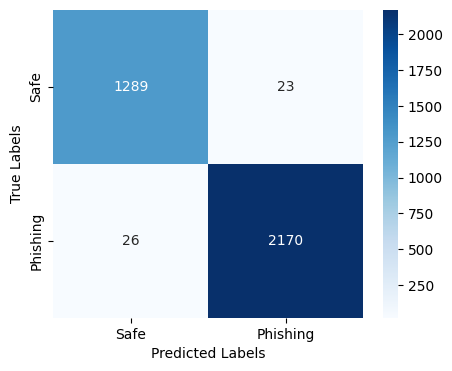


Classification Report:
               precision    recall  f1-score   support

        Safe       0.98      0.98      0.98      1312
    Phishing       0.99      0.99      0.99      2196

    accuracy                           0.99      3508
   macro avg       0.98      0.99      0.99      3508
weighted avg       0.99      0.99      0.99      3508

Balanced Accuracy: 0.985314901817051


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, balanced_accuracy_score

# Predictions
pred = trainer.predict(tokenized["test"])
logits, labels = pred.predictions, pred.label_ids
preds = np.argmax(logits, axis=-1)

# Confusion matrix
# Create confusion matrix
# Confusion matrix
cm = confusion_matrix(labels, preds,labels=[1,0])

# Reorder: Safe (1) first, Phishing (0) second
cm_ordered = cm[[1, 0], :][:, [1, 0]]

# Plot
plt.figure(figsize=(5,4))
sns.heatmap(cm_ordered, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Safe', 'Phishing'],
            yticklabels=['Safe', 'Phishing'])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.show()

# Classification report and balanced accuracy
print("\nClassification Report:\n", classification_report(labels, preds, target_names=class_order))
print("Balanced Accuracy:", balanced_accuracy_score(labels, preds))

In [ ]:
# --- Store DistilBERT results ---
distilbert_results = {
    "Model": "DistilBERT",
    "acc": accuracy_score(labels, preds),
    "pre": precision_score(labels, preds, average='binary', zero_division=0),
    "rec": recall_score(labels, preds, average='binary', zero_division=0),
    "f1": f1_score(labels, preds, average='binary', zero_division=0),
    "bal": balanced_accuracy_score(labels, preds)
}


In [ ]:
best_model_dir = os.path.join(OUTPUT_DIR, "best_model")
trainer.save_model(best_model_dir)
tokenizer.save_pretrained(best_model_dir)
print("✅ Model saved to:", best_model_dir)

In [ ]:
from transformers import pipeline

pipe = pipeline("text-classification", model=best_model_dir, tokenizer=best_model_dir, device=0 if torch.cuda.is_available() else -1)

def predict_email(text):
    out = pipe(text, truncation=True, max_length=MAX_LEN)[0]
    label_id = int(out["label"].split("_")[-1]) if out["label"].startswith("LABEL_") else 0
    label = le.inverse_transform([label_id])[0]
    human = "⚠️ Phishing Mail" if "phish" in label.lower() else "✅ Safe Mail"
    print(f"\nInput: {text}\nPrediction: {label} → {human} (score={out['score']:.3f})")

# Test examples
predict_email("Please verify your bank details immediately at http://fakebank.com")
predict_email("Reminder: project meeting tomorrow at 11 AM in the conference room.")
predict_email("Your account will be suspended. Update your password now!")

In [ ]:
df.to_csv("/content/drive/MyDrive/phishing_cleaned.csv", index=False)

In [ ]:
# Convert NB results to proper format
nb_results_df = pd.DataFrame(results).T.reset_index()
nb_results_df.rename(columns={"index": "Model"}, inplace=True)
# Convert DistilBERT to DataFrame
distilbert_df = pd.DataFrame([distilbert_results])

# Combine all models
final_results_df = pd.concat([nb_results_df, distilbert_df], ignore_index=True)

# Reorder columns
final_results_df = final_results_df[["Model", "acc", "pre", "rec", "f1", "bal"]]
final_results_df.to_csv("/content/drive/MyDrive/model_results.csv", index=False)
print("✅ Final model_results.csv saved with ALL models")

In [ ]:
cm_df = pd.DataFrame(cm, index=['Safe','Phishing'], columns=['Safe','Phishing'])
cm_df.to_csv("/content/drive/MyDrive/confusion_matrix_mnb.csv")

In [ ]:
sample_df = pd.DataFrame({
    "Email": X_test_text[:50],
    "Actual": y_test[:50],
    "Predicted": grid_mnb.best_estimator_.predict(X_test_tfidf[:50])
})
sample_df.to_csv("/content/drive/MyDrive/sample_predictions.csv")